# Obligatorio - Taller de Deep Learning


**Fecha de entrega:** 3/12/2025  
**Puntaje máximo:** 50 puntos

**Alumno(s):** 
Rodrigo Benitez - 172018 | 
Chia I Lin Liu - 172155

## Obligatorio

El objetivo de este obligatorio es evaluar su conocimiento en Deep Learning mediante la implementación completa de un modelo de segmentación de imágenes basado en el paper [**"U-Net: Convolutional Networks for Biomedical Image Segmentation"**](https://arxiv.org/pdf/1505.04597). Toda la implementación debe realizarse desde cero utilizando PyTorch, y los estudiantes tendrán la libertad de ajustar ciertos hiperparámetros y configuraciones mientras mantengan la esencia del paper original.

### **Competencia en Kaggle**

Además, como parte de este obligatorio, participarán en una competencia privada en Kaggle donde se les proporcionará un dataset de test oculto (sin target). Deberán subir sus predicciones a Kaggle y se evaluarán en función de la métrica **Dice Coefficient (Coeficiente de Dice)**. Esta competencia les permitirá comparar sus resultados con los de sus compañeros en un entorno real de evaluación.

### **¿Qué es el Dice Coefficient?**
El **Dice Coefficient**, también conocido como F1-score para segmentación, es una métrica utilizada para evaluar la similitud entre la predicción y la verdad del terreno en tareas de segmentación. Se define de la siguiente manera:

$$
\text{Dice} = \frac{2 \cdot |A \cap B|}{|A| + |B|}
$$

Donde:
- $A$ es el conjunto de píxeles predichos como pertenecientes a la clase positiva.
- $B$ es el conjunto de píxeles verdaderos pertenecientes a la clase positiva.
- $|A \cap B|$ es la intersección de $A$ y $B$, es decir, los píxeles correctamente predichos como positivos.

Un valor de Dice de **1** indica una predicción perfecta, mientras que un valor de **0** indica que no hay coincidencia entre la predicción y el valor verdadero. Durante la competencia de Kaggle, deberán obtener un puntaje de al menos **0.75** en la métrica Dice para considerarse aprobados.

### **Criterios a Evaluar**

1. **Análisis del Dataset (5 puntos):**
   - Exploración y visualización del dataset para comprender su estructura y características.
   - Justificación de las decisiones tomadas en la preprocesamiento de datos, como normalización, aumento de datos (data augmentation), y partición del dataset en conjuntos de entrenamiento, validación y prueba.

2. **Implementación Correcta del Modelo U-Net (20 puntos):**
   - Construcción de la arquitectura U-Net siguiendo la estructura descrita en el paper, permitiendo ajustes como el número de filtros, funciones de activación y métodos de inicialización de pesos.
   - Se aceptan mejoras como el uso de técnicas adicionales como batch normalization, otras funciones de activación, etc.

3. **Entrenamiento del Modelo (10 puntos):**
   - Configuración adecuada del ciclo de entrenamiento, incluyendo la elección de la función de pérdida y del optimizador (Adam, SGD, etc.).
   - Uso de técnicas de regularización para mejorar la generalización del modelo, como el dropout, normalización de batch y data augmentation.
   - Gráficas y análisis de la evolución del entrenamiento, mostrando las curvas de pérdida y métricas relevantes tanto en el conjunto de entrenamiento como en el de validación.
   - Puede utilizarse experimentación con hiperparámetros con Weights & Biases (W&B) para optimizar el rendimiento del modelo. Este punto no es obligatorio, pero se valorará positivamente si se justifica su uso y se presentan resultados claros.

4. **Evaluación de Resultados (10 puntos):**
   - Evaluación exhaustiva del modelo utilizando métricas de segmentación como **Dice Coefficient**.
   - Análisis detallado de los resultados, incluyendo un análisis de errores para identificar y discutir casos difíciles.
   - Visualización de ejemplos representativos de segmentaciones correctas e incorrectas, comparando con las etiquetas manuales proporcionadas en el dataset.

5. **Participación y Resultados en la Competencia Kaggle (5 puntos):**
   - Participación activa en la competencia de Kaggle, con al menos una (1) subida de predicción.
   - Puntaje obtenido en la tabla de posiciones de Kaggle, evaluado en base al **Dice Coefficient** en el conjunto de test oculto. Es necesario obtener al menos un valor de **0.75** para esta métrica.

   Notas: 
   - **Cualquier decisión debe ser justificada en el notebook.**
   - El **Dice Coefficient** es la métrica utilizada para evaluar la precisión de los modelos de segmentación de imágenes en esta competencia.

### **Run-Length Encoding (RLE)**

Dado que no se suben las imágenes segmentadas directamente a Kaggle, se requiere usar **Run-Length Encoding (RLE)** para comprimir las máscaras de predicción en una cadena de texto que será evaluada. El **RLE** es una técnica de compresión donde se representan secuencias consecutivas de píxeles en formato `start length`, indicando la posición de inicio y la longitud de cada secuencia de píxeles positivos.

Para calcular el **RLE**, se sigue el siguiente proceso:

1. Se aplanan las máscaras predichas en un solo vector
2. Se identifican los píxeles con valor positivo (1) y se calculan las secuencias consecutivas.
3. Se registra la posición de inicio de cada secuencia y su longitud en formato `start length`.

Este formato comprimido se sube a Kaggle en lugar de las imágenes segmentadas.

#### **Ejemplo de RLE**

```python
import numpy as np

def rle_encode(mask):
    pixels = np.array(mask).flatten(order='F')  # Aplanar la máscara en orden Fortran
    pixels = np.concatenate([[0], pixels, [0]])  # Añadir ceros al principio y final
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1  # Encontrar transiciones
    runs[1::2] = runs[1::2] - runs[::2]  # Calcular longitudes
    return ' '.join(str(x) for x in runs)

mask = np.array([[0, 0, 1, 0, 0],
                 [0, 1, 1, 1, 0],
                 [1, 1, 1, 0, 0],
                 [0, 0, 0, 1, 1]])

print(rle_encode(mask))
```

> **Salida:** 3 1 6 2 9 3 14 1 16 1 20 1


### **Sobre el Dataset**

El dataset proporcionado para esta tarea incluirá imágenes y máscaras para la segmentación de un conjunto específico de clases. El conjunto de entrenamiento estará disponible para su uso durante todo el proceso de desarrollo y pruebas, mientras que el conjunto de validación se mantendrá oculto para la evaluación final en Kaggle.

### **Instrucciones de Entrega**

- Deberán entregar un Jupyter Notebook (.ipynb) que contenga todo el código y las explicaciones necesarias para ejecutar la implementación, el entrenamiento y la evaluación del modelo.
- El notebook debe incluir secciones bien documentadas explicando las decisiones de diseño del modelo, los experimentos realizados, y los resultados obtenidos.
- El código debe estar escrito de manera clara.
- La entrega debe realizarse a través de la plataforma de gestión de ORT (gestion.ort.edu.uy) antes de la fecha límite.

### **Materiales Adicionales**

Para facilitar su trabajo, pueden consultar los siguientes recursos:

- [U-Net: Convolutional Networks for Biomedical Image Segmentation (paper original)](https://arxiv.org/abs/1505.04597)
- [Documentación de PyTorch](https://pytorch.org/docs/stable/index.html)
- [Tutoriales y recursos adicionales en Kaggle](https://www.kaggle.com/)
- [Convolución Transpuesta](https://d2l.ai/chapter_computer-vision/transposed-conv.html)

### **Competencia Kaggle**

[Link a la competencia Kaggle](https://www.kaggle.com/competitions/tdl-obligatorio-2025)

---

# Librerías

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split
from torchvision.transforms import v2 as T
from torchvision.io import read_image, ImageReadMode
from torchvision.datasets import Imagenette
from torchvision.datasets import ImageNet
from torchinfo import summary

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
import sys
import tarfile
import urllib.request
import re
from pathlib import Path
from collections import Counter
from itertools import chain

from sklearn.metrics import (
    accuracy_score,
    classification_report,
)

from utils import (
    train,
    model_calassification_report,
    show_tensor_image,
    show_tensor_images,
)


In [2]:
os.getcwd()

'/Users/rodrigobenitez/Documents/GitHub/ORT-AI/Deep Learning/Taller de DL/Tareas/Obligatorio'

In [3]:
# Fijamos la semilla para que los resultados sean reproducibles
SEED = 34

torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

In [4]:
import sys

# definimos el dispositivo que vamos a usar
DEVICE = "cpu"  # por defecto, usamos la CPU
if torch.cuda.is_available():
    DEVICE = "cuda"  # si hay GPU, usamos la GPU
elif torch.backends.mps.is_available():
    DEVICE = "mps"  # si no hay GPU, pero hay MPS, usamos MPS
elif torch.xpu.is_available():
    DEVICE = "xpu"  # si no hay GPU, pero hay XPU, usamos XPU

print(f"Usando {DEVICE}")

NUM_WORKERS = 0 # Win y MacOS pueden tener problemas con múltiples workers
if sys.platform == 'linux':
    NUM_WORKERS = 4  # numero de workers para cargar los datos (depende de cada caso)

print(f"Usando {NUM_WORKERS}")


Usando mps
Usando 0


In [5]:
BATCH_SIZE = 128  # tamaño del batch

# Config Weight & Bias

In [7]:
import wandb

In [8]:
wandb.login(key="371d1ec6f09f8bd9b3f43d38d319dae857ea940f")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/rodrigobenitez/.netrc
wandb: Currently logged in as: josefinalin (RoJo) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# Imagenes y mascaras

In [15]:
from typing import List, Optional, Tuple
import random
from PIL import Image

In [10]:
# Directorio de entrenamiento
TRAIN_DIR = Path("./data/train")
IMAGES_DIR = TRAIN_DIR / "images"
MASKS_DIR = TRAIN_DIR / "masks"

In [21]:
# Extensiones válidas para imágenes
VALID_EXTS = {".png"}

# Recolectamos imágenes disponibles
image_files: List[Path] = [p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in VALID_EXTS]
image_files.sort()
print(f"Imágenes encontradas: {len(image_files)} en {IMAGES_DIR}")

Imágenes encontradas: 2133 en data/train/images


In [14]:
# Helper para encontrar la máscara correspondiente por 'stem'
def find_mask_for_image(img_path: Path) -> Optional[Path]:
    stem = img_path.stem
    for ext in VALID_EXTS:
        candidate = MASKS_DIR / f"{stem}{ext}"
        if candidate.exists():
            return candidate
    # Si no coincide la extensión exacta, buscamos por cualquier extensión
    candidates = list(MASKS_DIR.glob(stem + ".*"))
    return candidates[0] if candidates else None

In [ ]:
# Visualización de una muestra aleatoria de pares imagen-máscara
NUM_SAMPLES = 6 
if len(image_files) == 0:
    raise RuntimeError("No se encontraron imágenes para visualizar")

sample_paths = random.sample(image_files, k=min(NUM_SAMPLES, len(image_files)))

In [ ]:
def ensure_same_size(img: Image.Image, mask: Image.Image) -> Tuple[Image.Image, Image.Image]:
    if img.size != mask.size:
        # Redimensionamos la máscara a la imagen usando NEAREST
        mask = mask.resize(img.size, resample=Image.NEAREST)
    return img, mask

In [ ]:
# Toggle para mostrar overlay
SHOW_OVERLAY = True
OVERLAY_COLOR = (255, 0, 0)  # rojo
ALPHA = 0.35

In [19]:
def overlay_mask_on_image(img: Image.Image, mask: Image.Image, color=(255, 0, 0), alpha=0.35) -> Image.Image:
    img_rgb = img.convert("RGB")
    mask_gray = mask.convert("L")
    mask_np = np.array(mask_gray)
    # Consideramos máscara binaria: cualquier valor > 0 como positivo
    bin_mask = (mask_np > 0).astype(np.uint8)

    overlay = np.array(img_rgb).astype(np.float32)
    color_arr = np.array(color, dtype=np.float32)

    # Aplicamos overlay solo en los píxeles de máscara
    overlay[bin_mask == 1] = (1 - alpha) * overlay[bin_mask == 1] + alpha * color_arr
    return Image.fromarray(np.clip(overlay, 0, 255).astype(np.uint8))

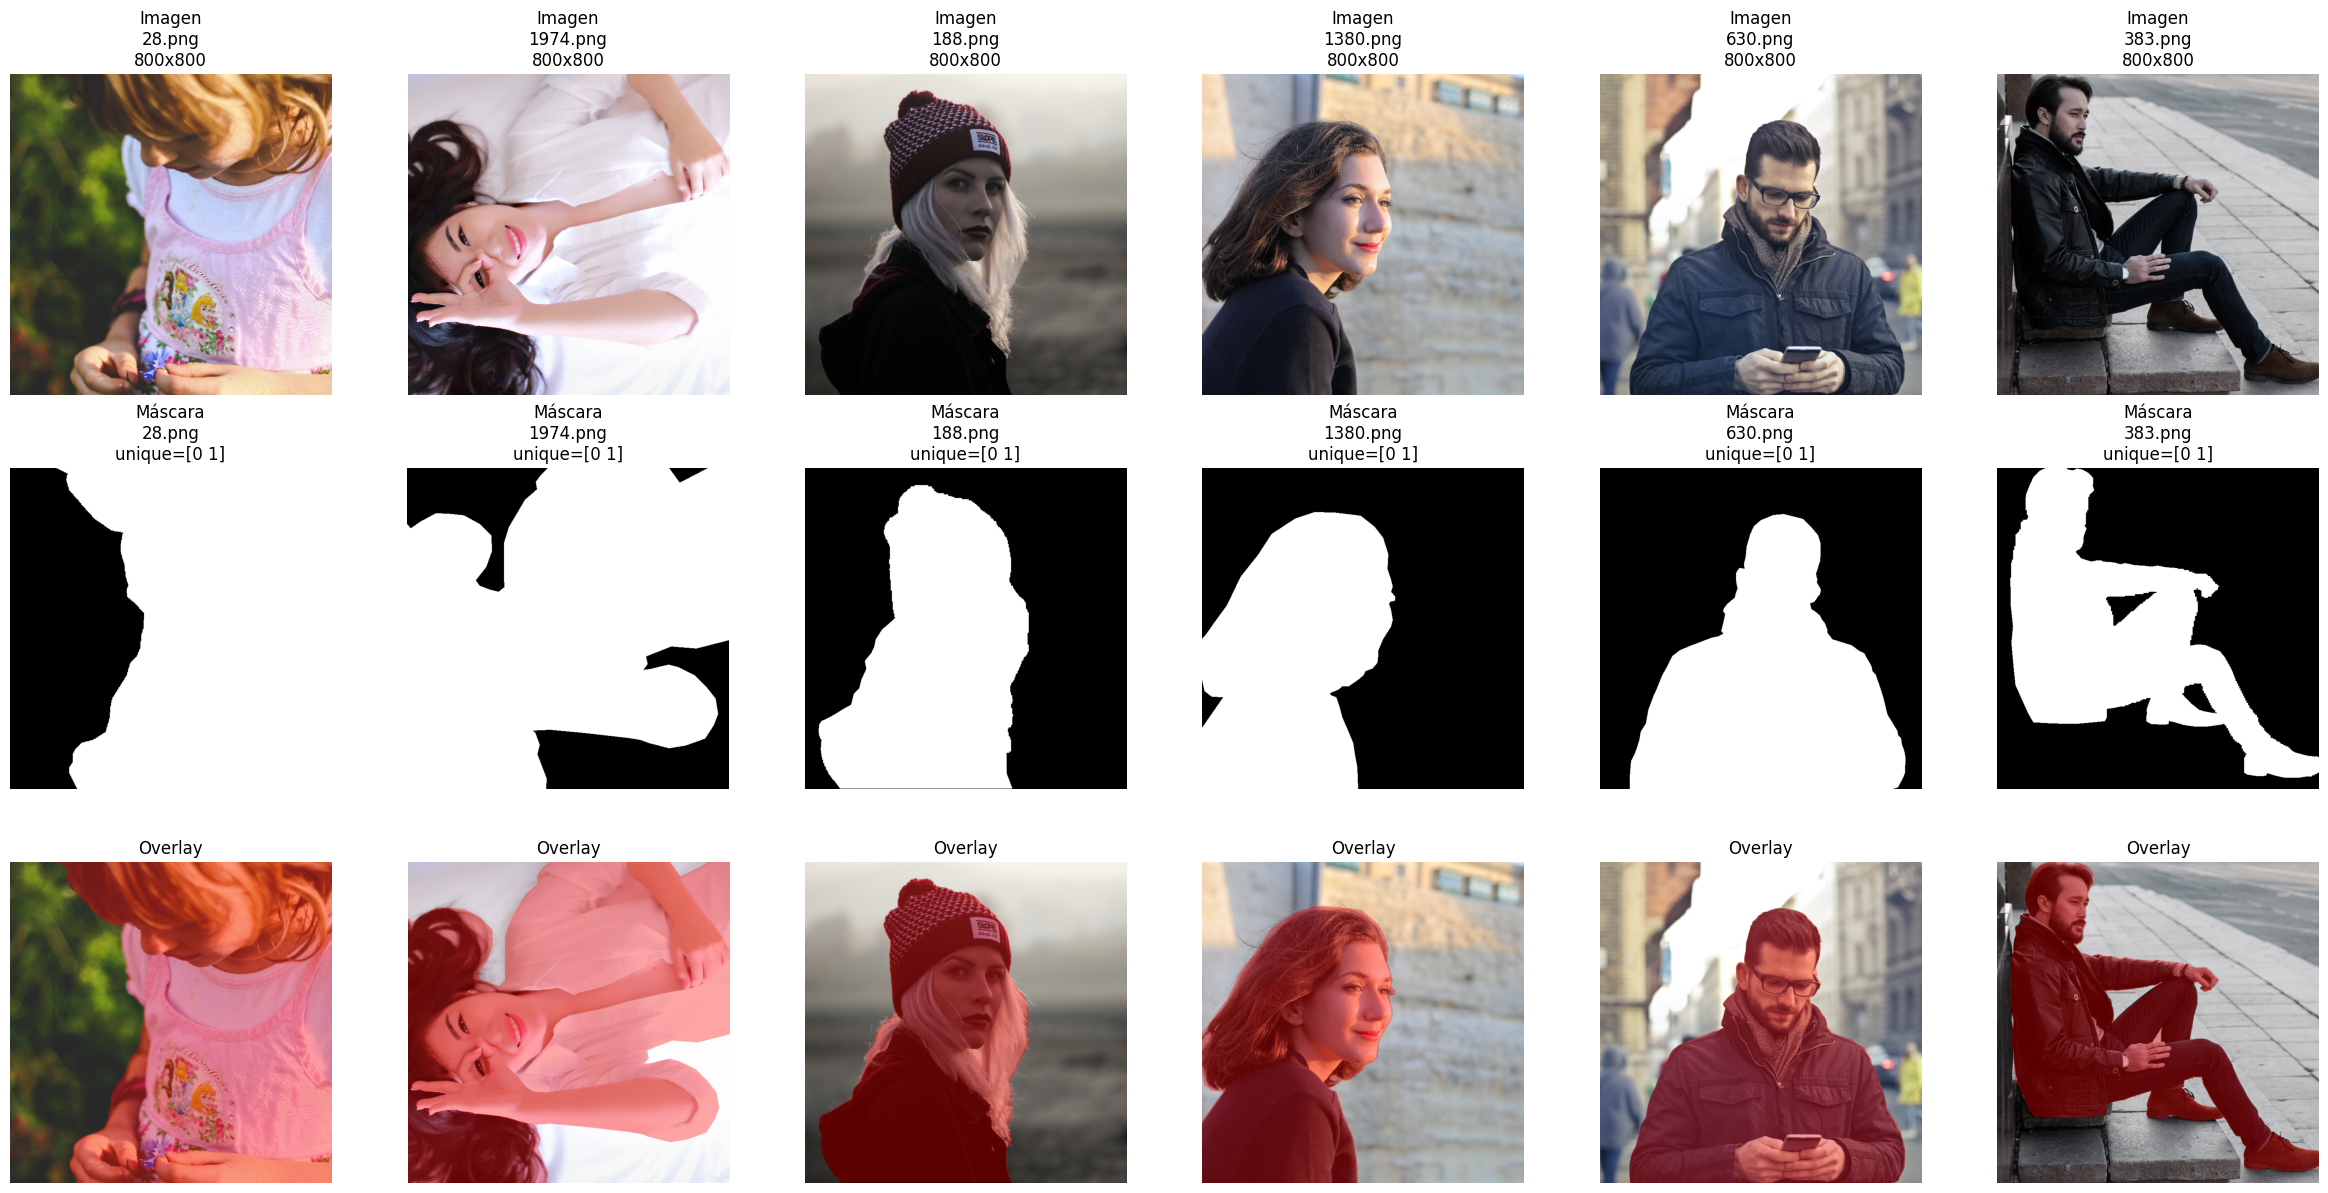

In [22]:
# Construimos las figuras
cols = len(sample_paths)
rows = 3 if SHOW_OVERLAY else 2
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
if cols == 1:
    axes = np.array(axes).reshape(rows, 1)

for j, img_path in enumerate(sample_paths):
    mask_path = find_mask_for_image(img_path)

    img = Image.open(img_path).convert("RGB")
    if mask_path is not None:
        mask = Image.open(mask_path).convert("L")
        img, mask = ensure_same_size(img, mask)
        mask_np = np.array(mask)
        uniq = np.unique(mask_np)
    else:
        mask = None
        uniq = None

    # Fila 0: imagen
    axes[0, j].imshow(img)
    axes[0, j].set_title(f"Imagen\n{img_path.name}\n{img.size[0]}x{img.size[1]}")
    axes[0, j].axis("off")

    # Fila 1: máscara si existe
    if mask is not None:
        axes[1, j].imshow(mask, cmap="gray")
        axes[1, j].set_title(
            f"Máscara\n{mask_path.name}\nunique={uniq[:8]}{'...' if uniq is not None and len(uniq) > 8 else ''}"
        )
        axes[1, j].axis("off")

    # Fila 2: Overlay
        if SHOW_OVERLAY:
            overlay = overlay_mask_on_image(img, mask, color=OVERLAY_COLOR, alpha=ALPHA)
            axes[2, j].imshow(overlay)
            axes[2, j].set_title("Overlay")
            axes[2, j].axis("off")
    else:
        axes[1, j].text(0.5, 0.5, "Sin máscara", ha="center", va="center")
        axes[1, j].axis("off")
        if SHOW_OVERLAY:
            axes[2, j].axis("off")

plt.tight_layout()
plt.show()

# Resumen breve
num_with_mask = sum(1 for p in image_files if find_mask_for_image(p) is not None)
